In [15]:
import matplotlib.pyplot as plt
import fev
import os

MODEL_CONFIG = {
    "causal":       ("Causal RevIN",           "#FF7F00"),  # vivid orange
    "causalsinh":   ("Causal RevIN + asinh",   "#573030"),  # dark brown
    "vanilla":      ("RevIN",                  "#00CC66"),  # vivid green
    "vanillasinh":  ("RevIN + asinh",          "#0055FF"),  # electric blue
    "prefix4":      ("Prefix@4 RevIN",         "#FF3300"),  # red-orange
    "prefix4sinh":  ("Prefix@4 RevIN + asinh", "#CC0099"),  # magenta
}

summaries = [
    "results/prefix4sinh.csv",
    "results/vanillasinh.csv",
    "results/prefix4.csv",
    "results/causal.csv",
    "results/vanilla.csv",
    "results/seasonal_naive.csv",
    "results/causalsinh.csv",
    ]

df = fev.leaderboard(summaries, baseline_model="Seasonal Naive")
remap_index  = {k: v[0] for k, v in MODEL_CONFIG.items()}
model_colors = {v[0]: v[1] for k, v in MODEL_CONFIG.items()}

df.index = df.index.map(lambda x: remap_index.get(x, x))
colors = [model_colors.get(m, "#333333") for m in df.index]
df.index = [m.replace("asinh", "$\sinh^{-1}$") for m in df.index]

df["win_rate"]*=100

df

,win_rate,skill_score,median_training_time_s,median_inference_time_s,training_corpus_overlap,num_failures
Prefix@4 RevIN + $\sinh^{-1}$,72.000000,0.364631,NaN,6.832274,0.0,0
Prefix@4 RevIN,65.500000,0.358489,NaN,6.797115,0.0,0
Causal RevIN,61.833333,0.314429,NaN,8.396742,0.0,0
Causal RevIN + $\sinh^{-1}$,55.166667,0.305643,NaN,8.130495,0.0,0
RevIN,43.166667,0.261686,NaN,6.841618,0.0,0
RevIN + $\sinh^{-1}$,36.500000,0.250600,NaN,8.194226,0.0,0
Seasonal Naive,15.833333,0.000000,0.0,2.220159,0.0,0


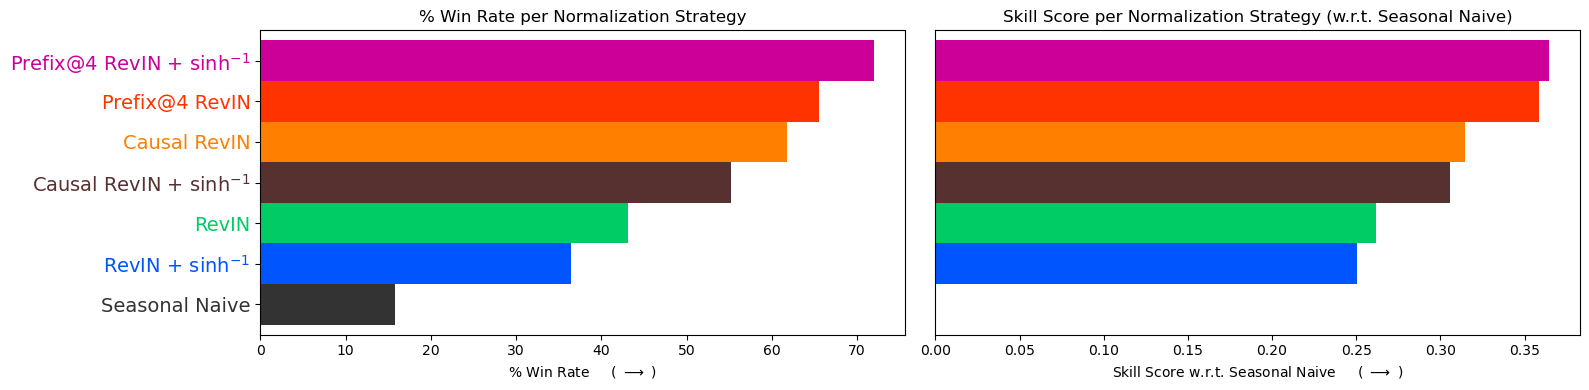

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df[["win_rate"]].plot.barh(
    ax=axes[0],
    y="win_rate",
    legend=False,
    title="% Win Rate per Normalization Strategy",
    color=colors,
    width=1,
)
axes[0].set_xlabel("% Win Rate     ( $\longrightarrow$ )")
axes[0].set_ylabel("")
axes[0].invert_yaxis()
axes[0].set_ymargin(0)

df[["skill_score"]].plot.barh(
    ax=axes[1],
    y="skill_score",
    legend=False,
    title="Skill Score per Normalization Strategy (w.r.t. Seasonal Naive)",
    color=colors,
    width=1,
)
axes[1].set_xlabel("Skill Score w.r.t. Seasonal Naive     ( $\longrightarrow$ )")
axes[1].set_yticklabels([])
axes[1].tick_params(left=False)
axes[1].set_ylabel("")
axes[1].invert_yaxis()
axes[1].set_ymargin(0)
for label, color in zip(axes[0].get_yticklabels(), colors):
    label.set_color(color)
    label.set_fontsize(14)

plt.tight_layout()
plt.savefig("results/leaderboard.pdf", dpi=300)
plt.show()